In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast 
from ast import literal_eval
import os
from pathlib import Path
from pandas import json_normalize

In [2]:
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.max_rows', None)  

In [95]:
#Se leeran todos los csv y se guardaran en diccionarios para acceder a ellos
carpeta = Path(r"C:\Users\sayur\OneDrive\Documentos\DataSets\elden-ring-data")
dataframes = {}
for archivo in carpeta.glob('*.csv'):
    nombre_tabla = archivo.stem  
    dataframes[nombre_tabla] = pd.read_csv(archivo,dtype=str, low_memory=False, na_filter=True)

In [5]:
#En las tablas que tenemos hay columnas que tienen sus diccionarios/listas en Strings, se convertiran en objetos
def procesar_archivo(ruta_archivo):
    try:
        if ruta_archivo.endswith(".csv"):
            df = pd.read_csv(ruta_archivo, dtype=str, low_memory=False)
        else:
            df = pd.read_excel(ruta_archivo, dtype=str)
        
        columnas_a_procesar = []
        for columna in df.columns:
            try:
                muestra = df[columna].dropna().head(5)
                if muestra.empty:
                    continue
                    
                if muestra.astype(str).str.startswith(('[', '{')).any():
                    primer_valor = ast.literal_eval(muestra.iloc[0])
                    if isinstance(primer_valor, (list, dict)):
                        columnas_a_procesar.append(columna)
            except:
                continue
        
        for columna in columnas_a_procesar:
            try:
                df[columna] = df[columna].apply(
                    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith(('[', '{')) else x
                )
            except Exception as e:
                print(f"Error procesando columna {columna}: {str(e)}")
                continue
        
        if ruta_archivo.endswith(".csv"):
            df.to_csv(ruta_archivo, index=False, encoding='utf-8-sig')
        else:
            df.to_excel(ruta_archivo, index=False)
        return True
    
    except Exception as e:
        print(f"Error procesando archivo {ruta_archivo}: {str(e)}")
        return False
        
def procesar_carpeta(carpeta):
    for archivo in os.listdir(carpeta):
        if archivo.endswith((".csv", ".xlsx")):
            ruta_completa = os.path.join(carpeta, archivo)
            try:
                if procesar_archivo(ruta_completa):
                    print(f"✅ Procesado exitoso: {archivo}")
                else:
                    print(f"⚠️ Archivo no procesado: {archivo}")
            except Exception as e:
                    print(f"❌ Error procesando {archivo}: {str(e)}")
            

 #Se indica la ruta de la carpeta en la que se quiere aplicar la funcion  

procesar_carpeta(r"C:\Users\sayur\OneDrive\Documentos\DataSets\elden-ring-data")

✅ Procesado exitoso: ammos.csv
✅ Procesado exitoso: armors.csv
✅ Procesado exitoso: ashesOfWar.csv
✅ Procesado exitoso: bells.csv
✅ Procesado exitoso: bosses.csv
✅ Procesado exitoso: classes.csv
✅ Procesado exitoso: consumables.csv
✅ Procesado exitoso: cookbooks.csv
✅ Procesado exitoso: creatures.csv
✅ Procesado exitoso: crystalTears.csv
✅ Procesado exitoso: greatRunes.csv
✅ Procesado exitoso: incantations.csv
✅ Procesado exitoso: keyItems.csv
✅ Procesado exitoso: locations.csv
✅ Procesado exitoso: materials.csv
✅ Procesado exitoso: multi.csv
✅ Procesado exitoso: npcs.csv
✅ Procesado exitoso: remembrances.csv
✅ Procesado exitoso: shields.csv
✅ Procesado exitoso: shields_upgrades.csv
✅ Procesado exitoso: skills.csv
✅ Procesado exitoso: sorceries.csv
✅ Procesado exitoso: spiritAshes.csv
✅ Procesado exitoso: talismans.csv
✅ Procesado exitoso: tools.csv
✅ Procesado exitoso: upgradeMaterials.csv
✅ Procesado exitoso: weapons.csv
✅ Procesado exitoso: weapons_upgrades.csv
✅ Procesado exitoso: 

In [96]:
#Se eliminaran columnas que no se ocuparan
columnas_a_eliminar = ['image', 'description']  # Columnas redundantes
for nombre_tabla, df in dataframes.items():  
  dataframes[nombre_tabla] = df.drop(columns=columnas_a_eliminar, errors='ignore')

In [97]:
df_weapons=dataframes['weapons']

In [103]:
df_weapons.head(5)

,id,weapon_id,name,weight,dlc,requirements,damage type,category,passive effect,skill,FP cost
0,0,1,Dueling Shield,9.0,1,"{'Str': 15, 'Dex': 14}",Standard/Pierce,Thrusting Shields,No passive effects,Shield Strike,0
1,1,2,Carian Thrusting Shield,10.5,1,"{'Str': 17, 'Dex': 13, 'Int': 15}",Standard/Pierce,Thrusting Shields,No passive effects,Shield Strike,0
2,2,3,Dryleaf Arts,1.0,1,"{'Str': 8, 'Dex': 8}",Strike,Hand-to-Hand Arts,No passive effects,Palm Blast,14
3,3,4,Dane's Footwork,1.0,1,"{'Str': 8, 'Dex': 8}",Strike,Hand-to-Hand Arts,No passive effects,Palm Blast,14
4,4,5,Smithscript Dagger,1.5,1,"{'Str': 5, 'Dex': 11, 'Int': 11, 'Fai': 11}",Pierce,Throwing Blades,No passive effects,Piercing Throw,6


In [114]:
pd.DataFrame(list(dataframes.keys()), columns=['Tablas'])

,Tablas
0,ammos
1,armors
2,ashesOfWar
3,bells
4,bosses
5,classes
6,consumables
7,cookbooks
8,creatures
9,crystalTears


<Axes: title={'center': 'Armas por categoría'}, xlabel='category'>

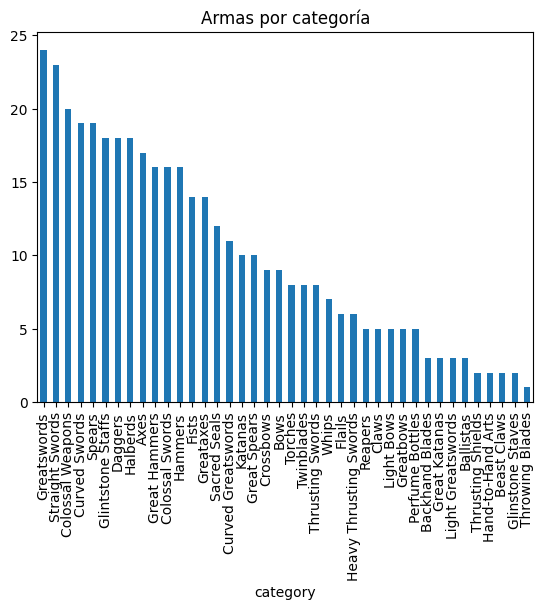

In [115]:
#Distribución de armas por categoría
df_weapons['category'].value_counts().plot(kind='bar', title='Armas por categoría')

In [116]:
#Estadísticas de peso y requisitos
df_weapons[['weight', 'FP cost']].describe()

,weight,FP cost
count,402,402
unique,63,89
top,2.5,0
freq,30,70


<Axes: title={'center': 'Dmg por tipo'}, xlabel='damage type'>

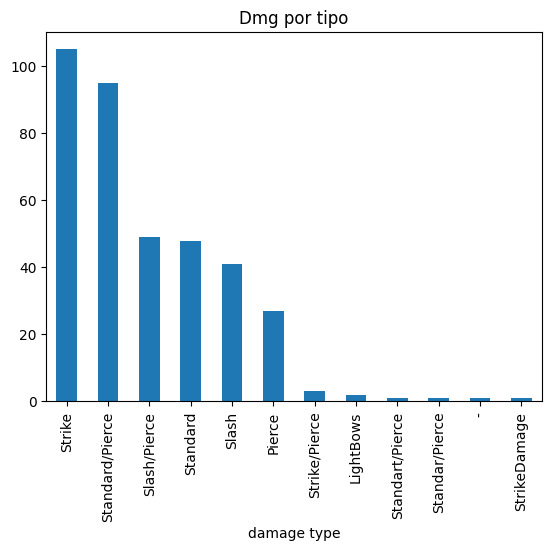

In [125]:
df_weapons['damage type'].value_counts().plot(kind='bar', title='Dmg por tipo')

In [127]:
#Skills mas comunes
df_weapons['skill'].value_counts().head(5)

skill
Spinning Slash     36
No Skill           31
Kick               26
Impaling Thrust    24
Quickstep          16
Name: count, dtype: int64

In [ ]:
# Convertir columnas numéricas
numeric_cols = ["weight", "FP cost", "requirements"]
df_weapons[numeric_cols] = df_weapons[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Eliminar filas con valores críticos faltantes
df_weapons.dropna(subset=["name", "weight"], inplace=True)

# Estandarizar "damage type"
df_weapons["damage_type"] = df_weapons["damage type"].str.split("/")
df_weapons = df_weapons.join(
    pd.get_dummies(df_weapons["damage_type"].explode()).groupby(level=0).sum()
)

# Eliminar columnas redundantes
df_weapons.drop(columns=["damage type", "requirements"], inplace=True, errors="ignore")

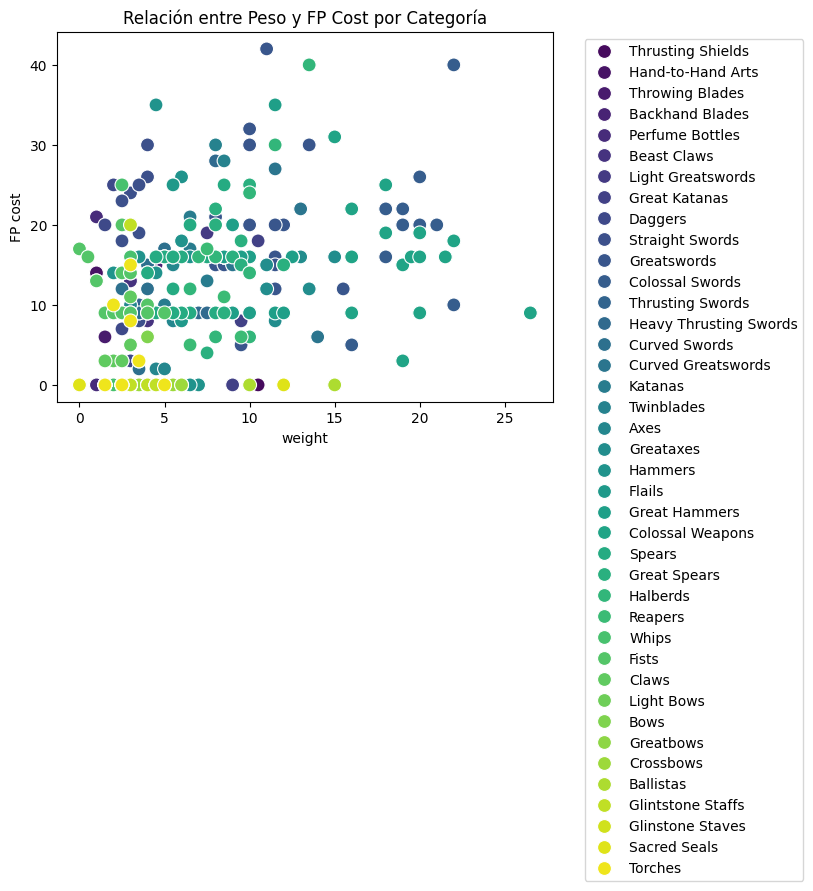

In [147]:
# Gráfico de dispersión con categorías
sns.scatterplot(
    data=df_weapons,
    x='weight',
    y='FP cost',
    hue='category',  # Color por categoría
    palette='viridis',
    s=100  # Tamaño de puntos
)
plt.title("Relación entre Peso y FP Cost por Categoría")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Mover leyenda
plt.show()